# Inferential Analysis — Logistic Regression
**SDS 357 — Spring 2026**

Logistic regression modeling P(Arrest | Driver Characteristics, Stop Conditions) to quantify the independent contribution of race, sex, and situational factors to arrest probability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

PALETTE_RACE = {"black": "#4C72B0", "white": "#DD8452",
                "hispanic": "#55A868", "asian/pacific islander": "#C44E52"}
RACE_ORDER = ["black", "white", "hispanic", "asian/pacific islander"]
CITY_ORDER = ["Charlotte", "Raleigh", "Greensboro", "Fayetteville", "Winston-Salem", "Durham"]
SEED = 42

## Data Loading & Preparation

In [2]:
df = pd.read_parquet("data/nc_traffic_stops_cleaned.parquet")
df = df[df["subject_race"].isin(RACE_ORDER)].copy()
df = df[~df["outcome_missing"]].copy()
df = df[df["hour"].notna() & df["subject_age"].notna()].copy()
df["hour"] = df["hour"].astype(int)
df["subject_age"] = df["subject_age"].astype(float)
df = df.reset_index(drop=True)

# Merge FBI crime rates (violent + property per 1k) by city-year
fbi = pd.read_csv("data/nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
df = df.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
              left_on=["city", "year"], right_on=["City", "Year"], how="left")
df.drop(columns=["City", "Year"], inplace=True)
# Fill years outside FBI coverage with city-level averages
city_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean()
for col in ["violent_crime_rate", "property_crime_rate"]:
    df[col] = df.apply(lambda r: city_avg.loc[r["city"], col]
                        if pd.isna(r[col]) else r[col], axis=1)

print(f"Dataset: {len(df):,} stops across {df['city'].nunique()} cities ({int(df['year'].min())}–{int(df['year'].max())})")
print(f"Arrest rate: {df['arrested'].mean()*100:.2f}%")
print(f"FBI crime rates merged: violent_crime_rate and property_crime_rate columns added")
df.head()

Dataset: 3,961,022 stops across 6 cities (2000–2015)
Arrest rate: 2.81%
FBI crime rates merged: violent_crime_rate and property_crime_rate columns added


,date,time,city,subject_race,subject_sex,subject_age,reason_for_stop,outcome,search_conducted,arrested,year,month,day_of_week,hour,outcome_missing,violent_crime_rate,property_crime_rate
0,2000-01-01,17:20:00,Charlotte,black,female,38.0,Safe Movement Violation,warning,False,0,2000,1,Saturday,17,False,7.461077,48.541918
1,2000-01-02,11:40:00,Charlotte,hispanic,male,33.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,11,False,7.461077,48.541918
2,2000-01-02,02:41:00,Charlotte,white,male,23.0,Vehicle Equipment Violation,citation,False,0,2000,1,Sunday,2,False,7.461077,48.541918
3,2000-01-23,03:35:00,Charlotte,white,female,23.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,3,False,7.461077,48.541918
4,2000-01-02,16:45:00,Charlotte,white,female,23.0,Safe Movement Violation,warning,False,0,2000,1,Sunday,16,False,7.461077,48.541918


## Inferential Analysis — Logistic Regression

P(Arrest | Driver Characteristics and Stop Conditions)

We use logistic regression to quantify the independent contribution of race, sex, and situational factors to the probability of arrest. All categorical variables are one-hot encoded with the first category dropped as a dummy variable. Library: `statsmodels`.

In [3]:
# Logistic Regression — full model with demographics + FBI crime rate
top_reasons = df["reason_for_stop"].value_counts().head(8).index.tolist()
dflog = df.copy()
dflog["reason_cat"] = dflog["reason_for_stop"].where(dflog["reason_for_stop"].isin(top_reasons), "Other")

X = pd.get_dummies(
    dflog[["subject_race", "subject_sex", "subject_age",
           "reason_cat", "city", "search_conducted", "hour", "year",
           "violent_crime_rate"]],
    columns=["subject_race", "subject_sex", "reason_cat", "city"],
    drop_first=True, dtype=float)
X["search_conducted"] = X["search_conducted"].astype(float)
X = sm.add_constant(X)
y = dflog["arrested"]
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

model = sm.Logit(y, X).fit(disp=0, maxiter=200)
print(f"Pseudo R²: {model.prsquared:.4f}")
print(f"Observations: {int(model.nobs):,}")

res = pd.DataFrame({
    "coef": model.params, "std_err": model.bse, "z": model.tvalues,
    "p_value": model.pvalues, "odds_ratio": np.exp(model.params),
    "or_ci_lower": np.exp(model.conf_int()[0]),
    "or_ci_upper": np.exp(model.conf_int()[1])
})
res[res["p_value"] < 0.05][["odds_ratio", "or_ci_lower", "or_ci_upper", "p_value"]].round(4)

Pseudo R²: 0.4563
Observations: 3,961,022


,odds_ratio,or_ci_lower,or_ci_upper,p_value
const,1.294092e+24,1.569444e+22,1.067050e+26,0.0
search_conducted,6.956530e+01,6.838050e+01,7.077070e+01,0.0
hour,9.746000e-01,9.737000e-01,9.756000e-01,0.0
year,9.708000e-01,9.687000e-01,9.729000e-01,0.0
subject_race_black,1.327000e+00,1.223700e+00,1.439000e+00,0.0
subject_race_hispanic,1.970800e+00,1.813800e+00,2.141500e+00,0.0
subject_race_white,1.234900e+00,1.138200e+00,1.339800e+00,0.0
subject_sex_male,1.305500e+00,1.281100e+00,1.330300e+00,0.0
reason_cat_Other,2.291940e+01,2.204850e+01,2.382470e+01,0.0
reason_cat_Other Motor Vehicle Violation,7.205000e-01,6.964000e-01,7.455000e-01,0.0


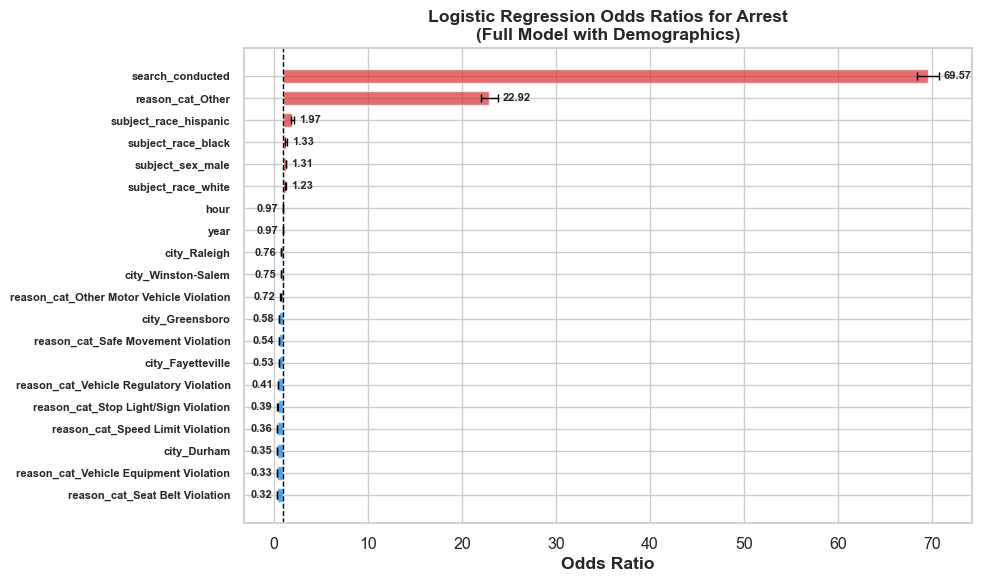

In [4]:
# Figure 4: Odds Ratios — significant features only
plot_df = res.drop(index=["const"], errors="ignore").copy()
plot_df = plot_df[plot_df["p_value"] < 0.05].sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d63031" if v > 1 else "#0984e3" for v in plot_df["odds_ratio"]]
ax.barh(range(len(plot_df)), plot_df["odds_ratio"] - 1, left=1,
        color=colors, alpha=0.7, height=0.6)
ax.errorbar(plot_df["odds_ratio"], range(len(plot_df)),
            xerr=[plot_df["odds_ratio"] - plot_df["or_ci_lower"],
                  plot_df["or_ci_upper"] - plot_df["odds_ratio"]],
            fmt="none", ecolor="black", capsize=3, linewidth=1)
for i, (idx, row) in enumerate(plot_df.iterrows()):
    orv = row["odds_ratio"]
    offset = row["or_ci_upper"] + 0.5 if orv >= 1 else row["or_ci_lower"] - 0.5
    ha = "left" if orv >= 1 else "right"
    ax.text(offset, i, f"{orv:.2f}", va="center", ha=ha, fontsize=8, fontweight="bold")
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8, fontweight="bold")
ax.set_xlabel("Odds Ratio", fontweight="bold")
ax.set_title("Logistic Regression Odds Ratios for Arrest\n(Full Model with Demographics)", fontweight="bold")
plt.tight_layout()
plt.show()